In [7]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### load network

In [9]:
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

missing keys: 0
unexpected keys: 0


### prior sampling

Prior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

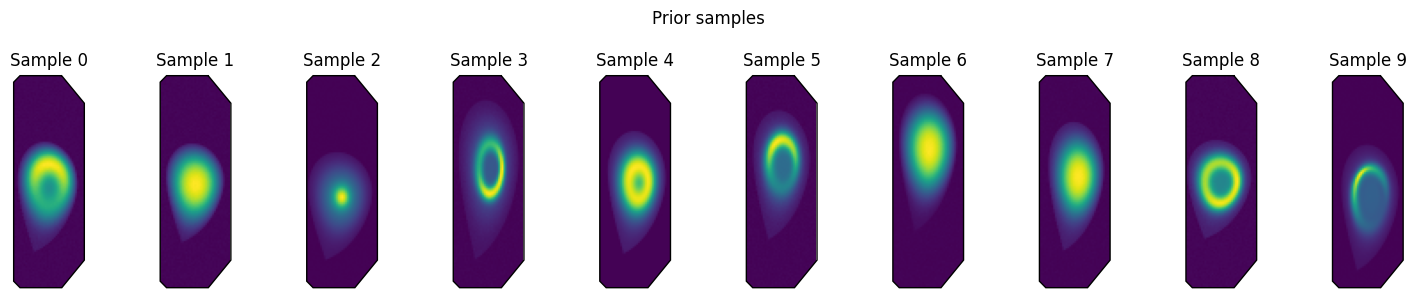

In [10]:
H, W = 120, 40
prior_samples = sample_prior(
    model=model,
    schedule=schedule,
    image_shape=(1, H, W),
    num_samples=99,
    num_inference_steps=250,   # increase to 1000 for full schedule
    eta=0.0,                   # 0: deterministic DDIM, >0: more stochastic
    clip_range=None,
)
show_samples(prior_samples[:10], ncols=10, title="Prior samples", figsize=(15,3))

### posterior sampling : denoising

Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

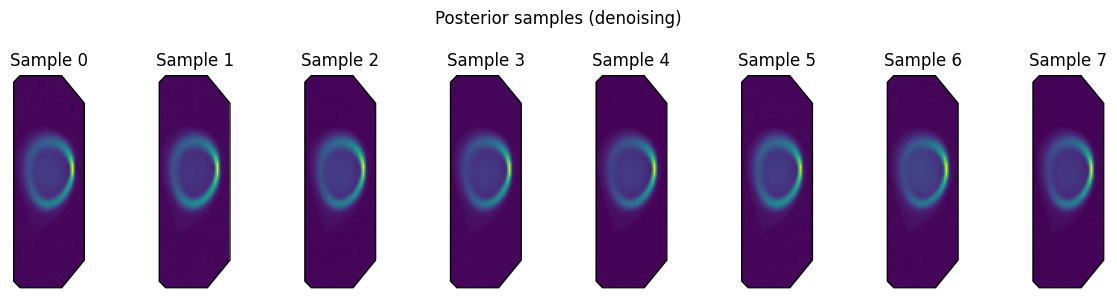

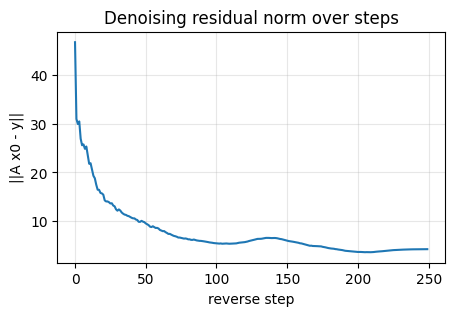

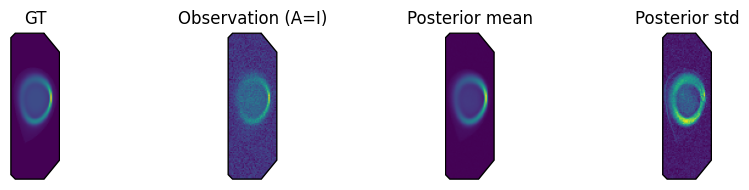

In [5]:
# ------------------------------
#  Build a ground-truth image x_gt
# ------------------------------
# Option A: load one training-like SXR profile from your local dataset path.
# Option B (fallback): use one prior sample as synthetic x_gt.

sample_idx = 2 #122
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]

x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

if x_gt is None:
    x_gt = prior_samples[:1].clone()
    print("No local sxr_sample_*.npy found. Using first prior sample as x_gt fallback.")

# ------------------------------
#  Posterior sampling: denoising (A = I)
# ------------------------------

n = H * W
A_denoise = torch.eye(n, device=device)

sigma_y_denoise = 0.05
y_denoise = x_gt.flatten() + sigma_y_denoise * torch.randn(n, device=device)

posterior_denoise, denoise_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_denoise,
    y=y_denoise,
    image_shape=(1, H, W),
    num_samples=8,
    num_inference_steps=250,
    zeta=0.6,
    sigma_y=sigma_y_denoise,
    lambda_=3000,
    clip_range=None,
)

show_samples(posterior_denoise[:8], title="Posterior samples (denoising)")

plt.figure(figsize=(5, 3))
plt.plot(denoise_residuals)
plt.title("Denoising residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()

# Compare denoising result: GT vs observation vs posterior stats
post_mean_denoise = posterior_denoise.mean(dim=0, keepdim=True)
post_std_denoise = posterior_denoise.std(dim=0, keepdim=True)

summary = torch.stack([
    x_gt[0, 0],
    y_denoise.view(H, W),
    post_mean_denoise[0, 0],
    post_std_denoise[0, 0],
])
show_samples(
    summary,
    titles=["GT", "Observation (A=I)", "Posterior mean", "Posterior std"],
    ncols=4,
    figsize=(10, 2),
)

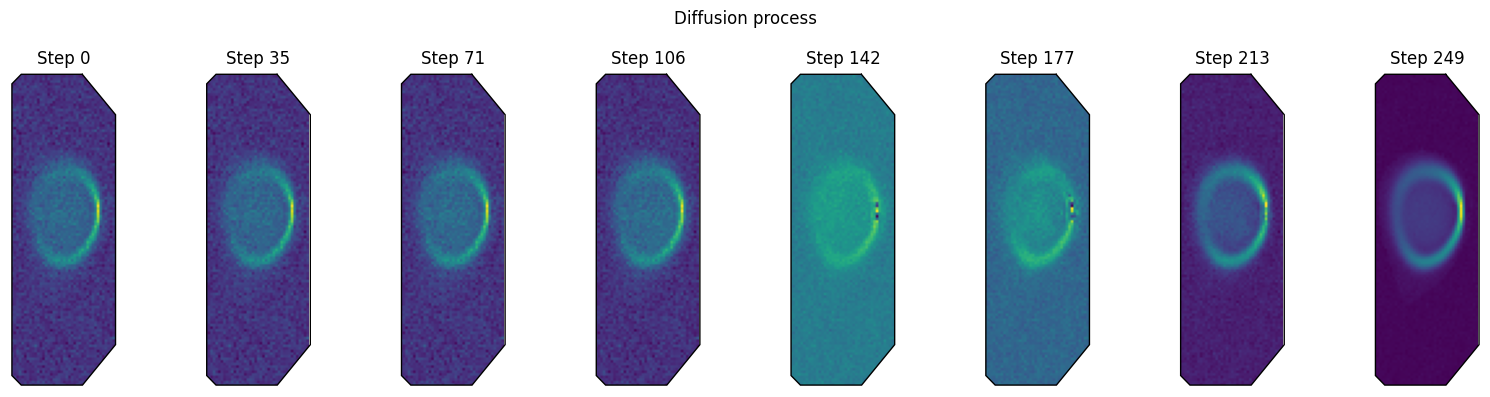

In [6]:
indices = np.linspace(0, len(diffusion_process) - 1, 8, dtype=int)
dp_tensor = torch.stack([diffusion_process[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process", 
)